# GWHD 2021 — YOLO26-Based Wheat Head Detection and Count-Based Yield Potential Estimation

This notebook implements a complete wheat head detection and count-based yield potential estimation workflow using GWHD 2021.

Main outputs:
1. Dataset analysis and visualization
2. CSV bounding box parsing
3. YOLO-format dataset conversion
4. YOLO26s and YOLO26m training with augmentation
5. Detection evaluation using Precision, Recall, F1-score, and mAP@0.5
6. Counting evaluation using MAE, RMSE, R², and MAPE
7. Domain-wise counting analysis
8. Ground-truth/prediction visualization and prediction confidence heatmap


## 1. Install and Import Required Libraries

In [1]:
!pip install -q -U ultralytics

import os
import random
import shutil
import yaml
import math
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
from ultralytics import YOLO

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Available GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23

## 2. Set Seed for Reproducibility

In [2]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic setting
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print("Seed fixed:", SEED)

Seed fixed: 42


## 3. Configuration

Expected dataset files:
- `competition_train.csv`
- `competition_val.csv`
- `competition_test.csv`
- `metadata_dataset.csv`
- `images/`

In [3]:
# Kaggle dataset path
BASE_PATH = Path("/kaggle/input/datasets/vbookshelf/global-wheat-head-dataset-2021/gwhd_2021")

# If your path is different, uncomment and edit:
# BASE_PATH = Path("../input/global-wheat-head-dataset-2021/gwhd_2021")

TRAIN_CSV = BASE_PATH / "competition_train.csv"
VAL_CSV   = BASE_PATH / "competition_val.csv"
TEST_CSV  = BASE_PATH / "competition_test.csv"
META_CSV  = BASE_PATH / "metadata_dataset.csv"
IMAGE_DIR = BASE_PATH / "images"

# Working directories
WORK_DIR = Path("/kaggle/working")
YOLO_DIR = WORK_DIR / "gwhd_yolo"
OUTPUT_DIR = WORK_DIR / "gwhd_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
RUNS_DIR = WORK_DIR / "runs_gwhd"

for d in [YOLO_DIR, OUTPUT_DIR, FIG_DIR, RUNS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Base path:", BASE_PATH)
print("Image dir exists:", IMAGE_DIR.exists())
print("Train CSV exists:", TRAIN_CSV.exists())
print("Val CSV exists:", VAL_CSV.exists())
print("Test CSV exists:", TEST_CSV.exists())
print("Metadata CSV exists:", META_CSV.exists())

Base path: /kaggle/input/datasets/vbookshelf/global-wheat-head-dataset-2021/gwhd_2021
Image dir exists: True
Train CSV exists: True
Val CSV exists: True
Test CSV exists: True
Metadata CSV exists: True


## 4. Load CSV Files

In [4]:
df_train = pd.read_csv(TRAIN_CSV)
df_val   = pd.read_csv(VAL_CSV)
df_test  = pd.read_csv(TEST_CSV)

# metadata uses semicolon separator
df_meta = pd.read_csv(META_CSV, sep=";")

print("Train shape:", df_train.shape)
print("Val shape:", df_val.shape)
print("Test shape:", df_test.shape)
print("Metadata shape:", df_meta.shape)

display(df_train.head())
display(df_val.head())
display(df_test.head())
display(df_meta.head())

Train shape: (3657, 3)
Val shape: (1476, 3)
Test shape: (1382, 3)
Metadata shape: (47, 4)


,image_name,BoxesString,domain
0,4563856cc6d75c670eafd86d5eb7245fbe8f273c28f9e3...,99 692 160 764;641 27 697 115;935 978 1012 102...,Arvalis_1
1,a2a15938845d9812de03bd44799c4b1bf856a8ad11752e...,230 143 321 222;928 929 1015 1004;485 557 604 ...,Arvalis_1
2,401f89a2bb6ab63e3f406bd59b9cadccfe953230feb6cd...,440 239 544 288;333 538 429 594;913 171 963 20...,Arvalis_1
3,0a3937653483c36dfb4d957b6f82ae96dbdc7ba36cc3d8...,112 274 188 303;892 812 958 847;0 889 67 928;1...,Arvalis_1
4,be1652110a44acd24b42784356e965ce84a04893c3f1bb...,810 204 863 314;360 231 425 408;452 348 510 47...,Arvalis_1


,image_name,BoxesString,domain
0,e6b6a900e5c54cd5d8b0649768c361512cff1813409319...,0 30 109 119;453 617 561 661;450 441 652 493;5...,Usask_1
1,53889799be1319296f102fa09a512463c27316a428bb9f...,38 370 88 443;924 824 964 874;0 191 39 265;828...,Usask_1
2,ec8f9365ca93eb9dab075c64e5c8b32edd4f8993e17b89...,884 932 1024 990;828 53 1024 206;607 633 681 7...,Usask_1
3,48bab0505514c876207b4ede1c60cc906947ca02bb4277...,284 114 352 181;421 0 533 90;910 326 954 409;8...,Usask_1
4,44bf4657132a886bea1b74e105c3aadfa41ba7a2ae9d7a...,94 0 241 183;173 217 318 338;401 371 606 472;3...,Usask_1


,image_name,BoxesString,domain
0,255b6ca9fea63f44125e5174bc932470b604c760430715...,481 820 604 922;655 957 732 1024;930 926 1013 ...,UQ_7
1,7f5eb37cab658de6fd0d688bf27f16e423794fed6184d8...,896 911 977 955;800 898 821 941;770 867 804 90...,UQ_7
2,7bcfff43b356f4a94948367782aa704a37ff4579baf45d...,892 993 922 1024;844 943 871 965;758 926 801 9...,UQ_7
3,e535384eda9d0f9c6ac57dd9397d5d614e4cad48c144d8...,648 886 722 1024;392 950 507 1024;876 677 981 ...,UQ_7
4,66e9fa7379fd7b7fd64024ac1b03b8e56f9ad020c10635...,559 939 623 1009;775 875 829 919;853 883 888 9...,UQ_7


,name,country,location,development_stage
0,Ethz_1,Switzerland,Usask,Filling
1,Rres_1,UK,Rothamsted,Filling - Ripening
2,ULiège-GxABT_1,Belgium,Gembloux,Ripening
3,NMBU_1,Norway,NMBU,Filling
4,NMBU_2,Norway,NMBU,Ripening


## 5. Parse Bounding Boxes

The CSV box format is:

```text
xmin ymin xmax ymax; xmin ymin xmax ymax; ...
```

For YOLO, this will later be converted to:

```text
class_id x_center y_center width height
```

Since this is a single-class dataset, `class_id = 0` for every box.

In [5]:
IMG_SIZE = 1024  # GWHD images are 1024x1024

def parse_boxes(box_str, img_size=1024):
    """Parse GWHD BoxesString into a list of [xmin, ymin, xmax, ymax]."""
    boxes = []

    if pd.isna(box_str):
        return boxes

    box_str = str(box_str).strip()
    if box_str == "":
        return boxes

    items = box_str.split(";")

    for item in items:
        item = item.strip()
        if item == "":
            continue

        parts = item.split()
        if len(parts) != 4:
            continue

        try:
            xmin, ymin, xmax, ymax = map(float, parts)
        except ValueError:
            continue

        # Clip coordinates into image boundary
        xmin = max(0, min(img_size, xmin))
        ymin = max(0, min(img_size, ymin))
        xmax = max(0, min(img_size, xmax))
        ymax = max(0, min(img_size, ymax))

        # Keep only valid boxes
        if xmax > xmin and ymax > ymin:
            boxes.append([xmin, ymin, xmax, ymax])

    return boxes


for df in [df_train, df_val, df_test]:
    df["boxes"] = df["BoxesString"].apply(parse_boxes)
    df["box_count"] = df["boxes"].apply(len)

print("Example parsed boxes:")
display(df_train[["image_name", "box_count", "boxes", "domain"]].head())

Example parsed boxes:


,image_name,box_count,boxes,domain
0,4563856cc6d75c670eafd86d5eb7245fbe8f273c28f9e3...,41,"[[99.0, 692.0, 160.0, 764.0], [641.0, 27.0, 69...",Arvalis_1
1,a2a15938845d9812de03bd44799c4b1bf856a8ad11752e...,41,"[[230.0, 143.0, 321.0, 222.0], [928.0, 929.0, ...",Arvalis_1
2,401f89a2bb6ab63e3f406bd59b9cadccfe953230feb6cd...,52,"[[440.0, 239.0, 544.0, 288.0], [333.0, 538.0, ...",Arvalis_1
3,0a3937653483c36dfb4d957b6f82ae96dbdc7ba36cc3d8...,43,"[[112.0, 274.0, 188.0, 303.0], [892.0, 812.0, ...",Arvalis_1
4,be1652110a44acd24b42784356e965ce84a04893c3f1bb...,43,"[[810.0, 204.0, 863.0, 314.0], [360.0, 231.0, ...",Arvalis_1


## 6. Dataset Overview and Distribution

In [6]:
split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [len(df_train), len(df_val), len(df_test)],
    "Total_Boxes": [df_train["box_count"].sum(), df_val["box_count"].sum(), df_test["box_count"].sum()],
    "Avg_Boxes_Per_Image": [df_train["box_count"].mean(), df_val["box_count"].mean(), df_test["box_count"].mean()],
    "Min_Boxes": [df_train["box_count"].min(), df_val["box_count"].min(), df_test["box_count"].min()],
    "Max_Boxes": [df_train["box_count"].max(), df_val["box_count"].max(), df_test["box_count"].max()],
    "Domains": [df_train["domain"].nunique(), df_val["domain"].nunique(), df_test["domain"].nunique()],
})

display(split_summary)

split_summary.to_csv(OUTPUT_DIR / "dataset_split_summary.csv", index=False)
print("Saved:", OUTPUT_DIR / "dataset_split_summary.csv")

,Split,Images,Total_Boxes,Avg_Boxes_Per_Image,Min_Boxes,Max_Boxes,Domains
0,Train,3657,163690,44.760733,0,129,18
1,Validation,1476,44347,30.045393,0,179,11
2,Test,1382,67424,48.787265,0,190,18


Saved: /kaggle/working/gwhd_outputs/dataset_split_summary.csv


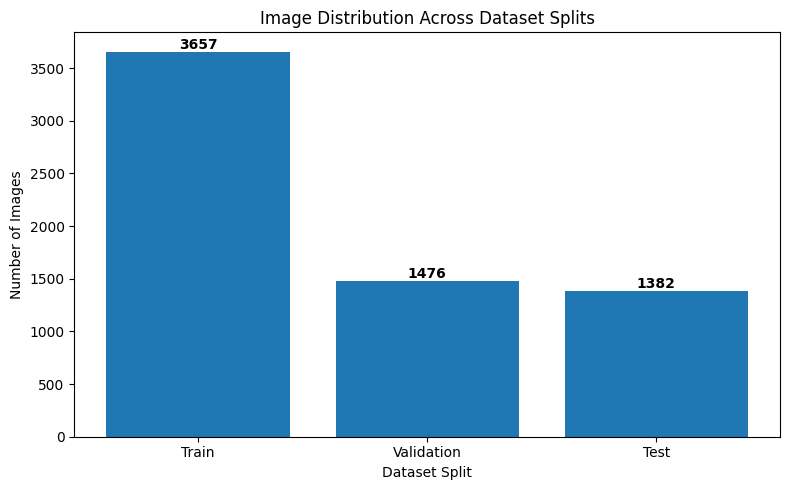

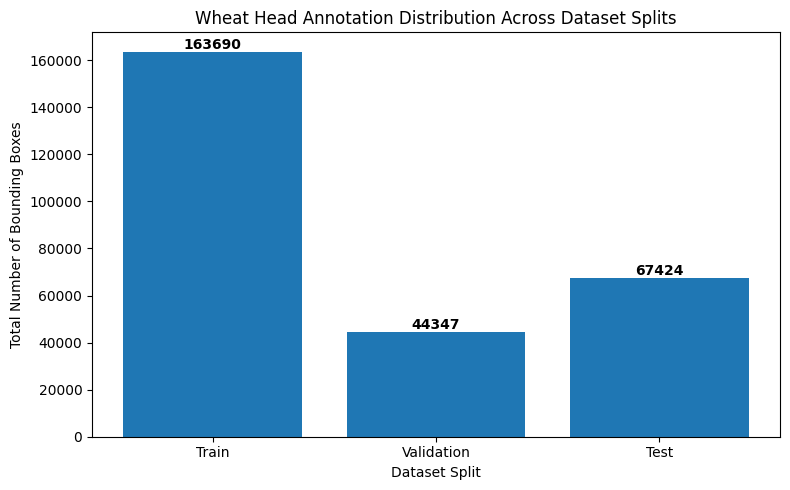

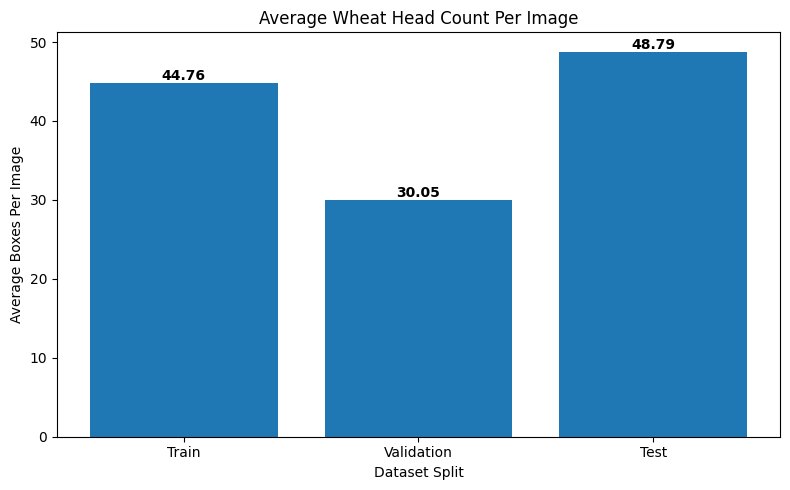

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(split_summary["Split"], split_summary["Images"])
plt.title("Image Distribution Across Dataset Splits")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

for i, v in enumerate(split_summary["Images"]):
    plt.text(i, v, str(v), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "image_distribution.png", dpi=300)
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(split_summary["Split"], split_summary["Total_Boxes"])
plt.title("Wheat Head Annotation Distribution Across Dataset Splits")
plt.xlabel("Dataset Split")
plt.ylabel("Total Number of Bounding Boxes")

for i, v in enumerate(split_summary["Total_Boxes"]):
    plt.text(i, v, str(int(v)), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "box_distribution.png", dpi=300)
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(split_summary["Split"], split_summary["Avg_Boxes_Per_Image"])
plt.title("Average Wheat Head Count Per Image")
plt.xlabel("Dataset Split")
plt.ylabel("Average Boxes Per Image")

for i, v in enumerate(split_summary["Avg_Boxes_Per_Image"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "average_boxes_per_image.png", dpi=300)
plt.show()

## 7. Domain-wise Distribution

,split,domain,images,total_boxes,avg_boxes_per_image
0,test,ARC_1,30,1169,38.966667
1,test,CIMMYT_1,69,2843,41.202899
2,test,CIMMYT_2,77,2771,35.987013
3,test,CIMMYT_3,60,1554,25.900000
4,test,KSU_1,100,6435,64.350000
5,test,KSU_2,100,5302,53.020000
6,test,KSU_3,95,5217,54.915789
7,test,KSU_4,60,3285,54.750000
8,test,NAU_2,100,4918,49.180000
9,test,NAU_3,100,4596,45.960000


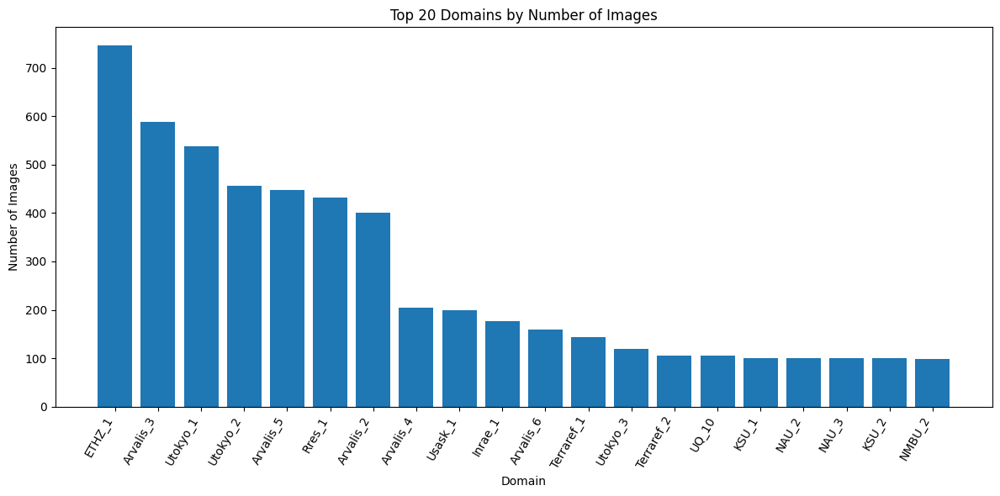

In [8]:
def add_split_name(df, split):
    temp = df.copy()
    temp["split"] = split
    return temp

df_all = pd.concat([
    add_split_name(df_train, "train"),
    add_split_name(df_val, "val"),
    add_split_name(df_test, "test")
], ignore_index=True)

domain_summary = df_all.groupby(["split", "domain"]).agg(
    images=("image_name", "count"),
    total_boxes=("box_count", "sum"),
    avg_boxes_per_image=("box_count", "mean")
).reset_index()

display(domain_summary.head(20))
domain_summary.to_csv(OUTPUT_DIR / "domain_summary.csv", index=False)

# Top 20 domains by image count
top_domains = df_all["domain"].value_counts().head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_domains.index, top_domains.values)
plt.title("Top 20 Domains by Number of Images")
plt.xlabel("Domain")
plt.ylabel("Number of Images")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_20_domains.png", dpi=300)
plt.show()

## 8. Bounding Box Size Distribution

In [9]:
def boxes_to_dataframe(df, split):
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split} boxes"):
        for box in row["boxes"]:
            xmin, ymin, xmax, ymax = box
            w = xmax - xmin
            h = ymax - ymin
            area = w * h
            rows.append({
                "split": split,
                "image_name": row["image_name"],
                "domain": row["domain"],
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
                "width": w,
                "height": h,
                "area": area,
                "area_ratio": area / (IMG_SIZE * IMG_SIZE)
            })
    return pd.DataFrame(rows)

boxes_train = boxes_to_dataframe(df_train, "train")
boxes_val   = boxes_to_dataframe(df_val, "val")
boxes_test  = boxes_to_dataframe(df_test, "test")

boxes_all = pd.concat([boxes_train, boxes_val, boxes_test], ignore_index=True)
boxes_all.to_csv(OUTPUT_DIR / "all_bounding_boxes.csv", index=False)

display(boxes_all.describe())

Processing train boxes:   0%|          | 0/3657 [00:00<?, ?it/s]

Processing val boxes:   0%|          | 0/1476 [00:00<?, ?it/s]

Processing test boxes:   0%|          | 0/1382 [00:00<?, ?it/s]

,xmin,ymin,xmax,ymax,width,height,area,area_ratio
count,275461.000000,275461.000000,275461.000000,275461.000000,275461.000000,275461.000000,275461.000000,275461.000000
mean,475.457045,477.030589,552.078109,549.567906,76.621064,72.537317,6160.581229,0.005875
std,300.372225,297.932225,299.154881,296.829331,38.989938,38.166722,6075.871509,0.005794
min,0.000000,0.000000,1.000000,4.000000,1.000000,1.000000,3.000000,0.000003
25%,211.000000,219.000000,292.000000,293.000000,50.000000,47.000000,2596.000000,0.002476
50%,477.000000,478.000000,554.000000,553.000000,70.000000,65.000000,4544.000000,0.004333
75%,737.000000,736.000000,815.000000,808.000000,94.000000,89.000000,7623.000000,0.007270
max,1020.000000,1023.000000,1024.000000,1024.000000,705.000000,610.000000,387960.000000,0.369987


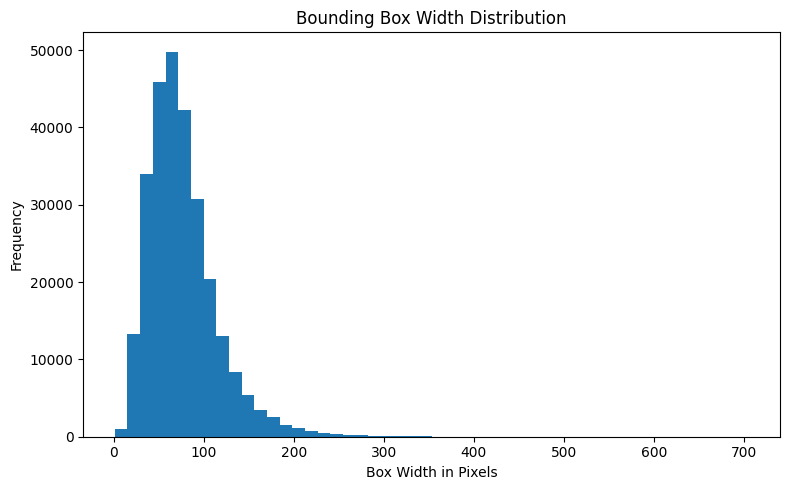

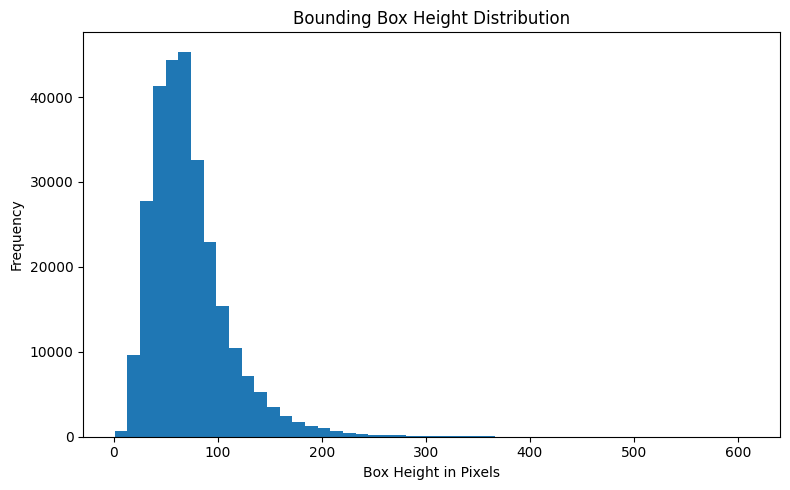

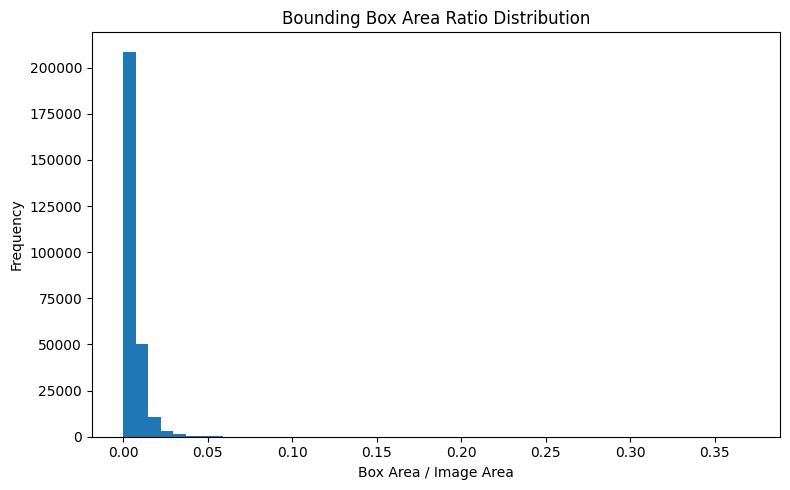

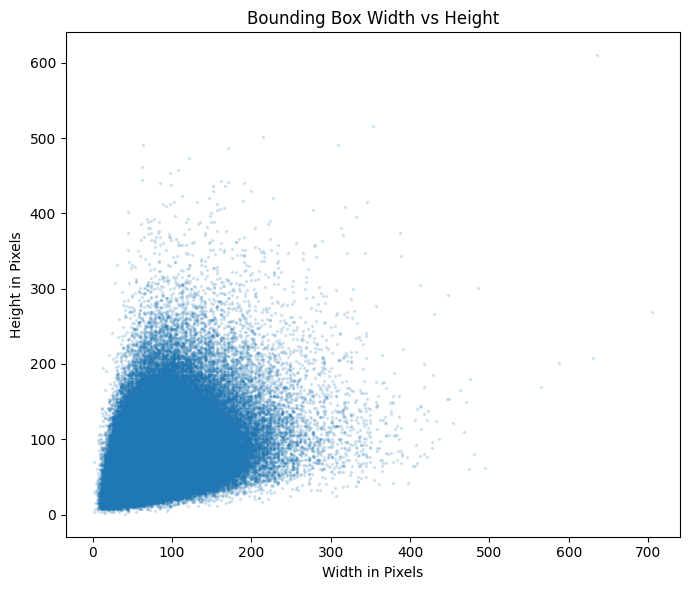

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(boxes_all["width"], bins=50)
plt.title("Bounding Box Width Distribution")
plt.xlabel("Box Width in Pixels")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "bbox_width_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(boxes_all["height"], bins=50)
plt.title("Bounding Box Height Distribution")
plt.xlabel("Box Height in Pixels")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "bbox_height_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(boxes_all["area_ratio"], bins=50)
plt.title("Bounding Box Area Ratio Distribution")
plt.xlabel("Box Area / Image Area")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "bbox_area_ratio_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(boxes_all["width"], boxes_all["height"], s=2, alpha=0.15)
plt.title("Bounding Box Width vs Height")
plt.xlabel("Width in Pixels")
plt.ylabel("Height in Pixels")
plt.tight_layout()
plt.savefig(FIG_DIR / "bbox_width_height_scatter.png", dpi=300)
plt.show()

## 9. Visualize Ground Truth Bounding Boxes

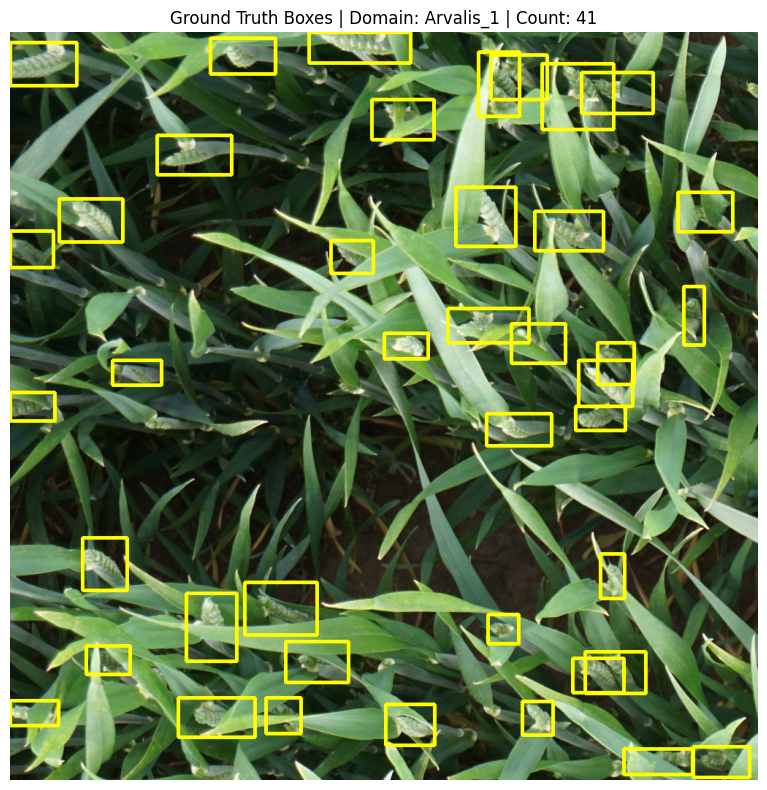

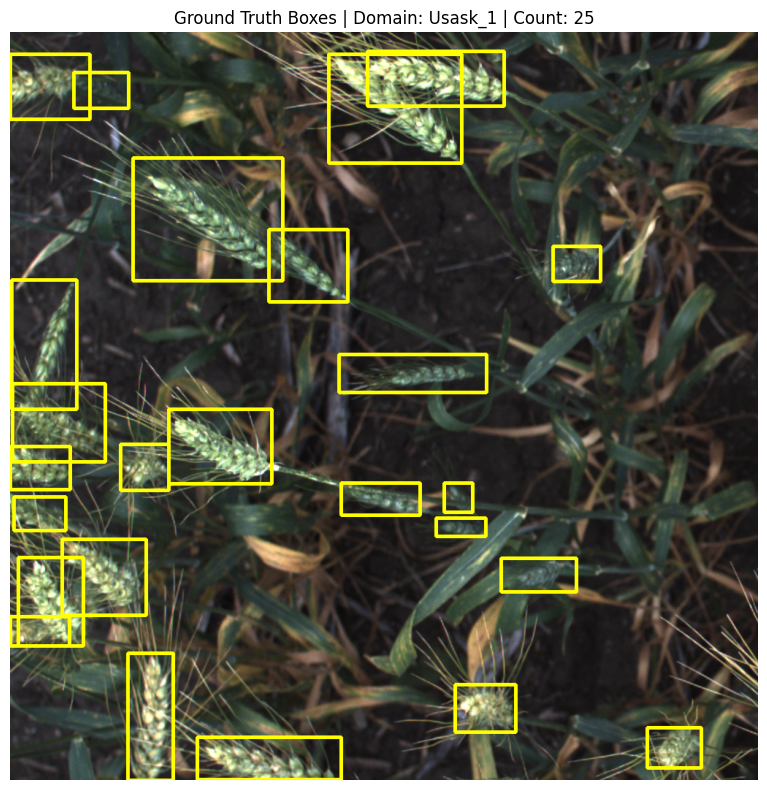

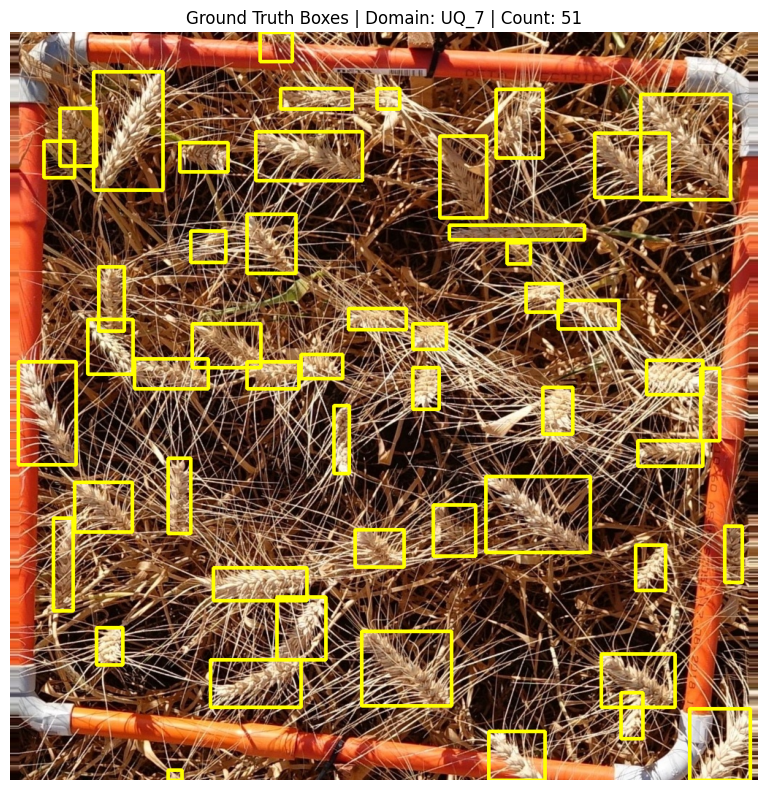

In [11]:
def draw_boxes_on_image(image_path, boxes, color=(255, 255, 0), thickness=3):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    for box in boxes:
        xmin, ymin, xmax, ymax = map(int, box)
        cv2.rectangle(image_rgb, (xmin, ymin), (xmax, ymax), color, thickness)

    return image_rgb


def show_ground_truth_sample(df, idx=0, save_name=None):
    row = df.iloc[idx]
    image_path = IMAGE_DIR / row["image_name"]
    image_with_boxes = draw_boxes_on_image(image_path, row["boxes"])

    plt.figure(figsize=(8, 8))
    plt.imshow(image_with_boxes)
    plt.title(f"Ground Truth Boxes | Domain: {row['domain']} | Count: {row['box_count']}")
    plt.axis("off")
    plt.tight_layout()

    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=300, bbox_inches="tight")

    plt.show()


show_ground_truth_sample(df_train, idx=0, save_name="sample_ground_truth_train.png")
show_ground_truth_sample(df_val, idx=0, save_name="sample_ground_truth_val.png")
show_ground_truth_sample(df_test, idx=0, save_name="sample_ground_truth_test.png")

## 10. Convert GWHD CSV Annotation to YOLO Format

YOLO label format:

```text
0 x_center y_center width height
```

All values are normalized between 0 and 1.

In [12]:
def bbox_to_yolo(box, img_w=1024, img_h=1024):
    xmin, ymin, xmax, ymax = box

    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    width = (xmax - xmin) / img_w
    height = (ymax - ymin) / img_h

    # Clip into valid YOLO range
    x_center = min(max(x_center, 0), 1)
    y_center = min(max(y_center, 0), 1)
    width = min(max(width, 0), 1)
    height = min(max(height, 0), 1)

    return x_center, y_center, width, height


def link_or_copy(src, dst):
    """Use symlink to save space. If symlink fails, copy file."""
    dst.parent.mkdir(parents=True, exist_ok=True)

    if dst.exists() or dst.is_symlink():
        return

    try:
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)


def create_yolo_split(df, split_name):
    images_out = YOLO_DIR / "images" / split_name
    labels_out = YOLO_DIR / "labels" / split_name

    images_out.mkdir(parents=True, exist_ok=True)
    labels_out.mkdir(parents=True, exist_ok=True)

    missing_images = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Creating YOLO {split_name}"):
        img_name = row["image_name"]
        src_img = IMAGE_DIR / img_name
        dst_img = images_out / img_name

        if not src_img.exists():
            missing_images += 1
            continue

        link_or_copy(src_img, dst_img)

        label_name = Path(img_name).stem + ".txt"
        label_path = labels_out / label_name

        yolo_lines = []
        for box in row["boxes"]:
            x_center, y_center, w, h = bbox_to_yolo(box, IMG_SIZE, IMG_SIZE)
            yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

        with open(label_path, "w") as f:
            f.write("\n".join(yolo_lines))

    print(f"{split_name}: missing images = {missing_images}")


# Create YOLO dataset
create_yolo_split(df_train, "train")
create_yolo_split(df_val, "val")
create_yolo_split(df_test, "test")

print("YOLO dataset created at:", YOLO_DIR)

Creating YOLO train:   0%|          | 0/3657 [00:00<?, ?it/s]

train: missing images = 0


Creating YOLO val:   0%|          | 0/1476 [00:00<?, ?it/s]

val: missing images = 0


Creating YOLO test:   0%|          | 0/1382 [00:00<?, ?it/s]

test: missing images = 0
YOLO dataset created at: /kaggle/working/gwhd_yolo


## 11. Create YOLO Data YAML File

In [13]:
data_yaml = {
    "path": str(YOLO_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 1,
    "names": ["wheat_head"]
}

DATA_YAML = YOLO_DIR / "gwhd.yaml"

with open(DATA_YAML, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("Saved YAML:", DATA_YAML)
print(open(DATA_YAML).read())

Saved YAML: /kaggle/working/gwhd_yolo/gwhd.yaml
path: /kaggle/working/gwhd_yolo
train: images/train
val: images/val
test: images/test
nc: 1
names:
- wheat_head



## 12. Verify YOLO Labels by Drawing One Converted Label

This step checks whether the YOLO label conversion is correct.

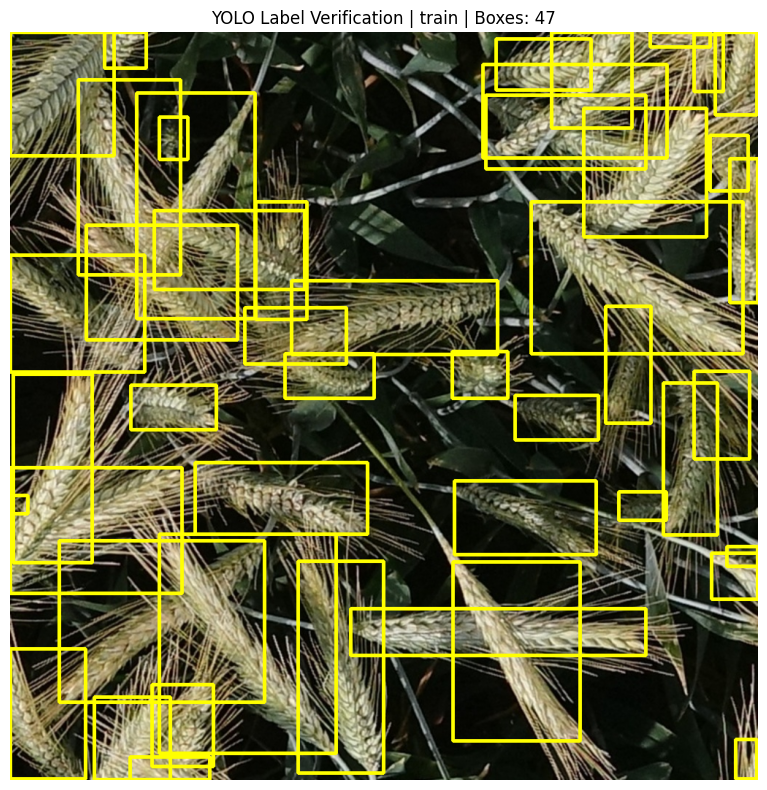

In [14]:
def yolo_to_bbox(yolo_line, img_w=1024, img_h=1024):
    parts = yolo_line.strip().split()
    cls_id, x_center, y_center, w, h = map(float, parts)

    xmin = int((x_center - w / 2) * img_w)
    ymin = int((y_center - h / 2) * img_h)
    xmax = int((x_center + w / 2) * img_w)
    ymax = int((y_center + h / 2) * img_h)

    return [xmin, ymin, xmax, ymax]


def visualize_yolo_label(split="train", idx=0):
    img_files = sorted((YOLO_DIR / "images" / split).glob("*"))
    image_path = img_files[idx]
    label_path = YOLO_DIR / "labels" / split / (image_path.stem + ".txt")

    with open(label_path, "r") as f:
        lines = [line for line in f.read().splitlines() if line.strip()]

    boxes = [yolo_to_bbox(line, IMG_SIZE, IMG_SIZE) for line in lines]
    image_with_boxes = draw_boxes_on_image(image_path, boxes)

    plt.figure(figsize=(8, 8))
    plt.imshow(image_with_boxes)
    plt.title(f"YOLO Label Verification | {split} | Boxes: {len(boxes)}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"yolo_label_verification_{split}.png", dpi=300, bbox_inches="tight")
    plt.show()


visualize_yolo_label(split="train", idx=0)

## 13. Train YOLO26 Models

Two YOLO26 variants are trained:
- `YOLO26s` as the lighter comparison model
- `YOLO26m` as the main higher-capacity model

Augmentation is enabled during training to improve robustness under different field conditions, lighting variations, and wheat head density patterns.


In [15]:
EPOCHS = 80
IMG_SIZE_TRAIN = 640
BATCH_SIZE = 16
PATIENCE = 15

if torch.cuda.device_count() >= 2:
    DEVICE = "0,1"
elif torch.cuda.is_available():
    DEVICE = 0
else:
    DEVICE = "cpu"

MODEL_LIST = [
    "yolo26s.pt",
    "yolo26m.pt"
]

trained_model_paths = {}

for model_weight in MODEL_LIST:
    exp_name = model_weight.replace(".pt", "") + "_gwhd_aug"

    print("=" * 80)
    print("Training:", model_weight)
    print("Experiment name:", exp_name)
    print("Image size:", IMG_SIZE_TRAIN)
    print("Batch size:", BATCH_SIZE)
    print("Device:", DEVICE)
    print("=" * 80)

    model = YOLO(model_weight)

    results = model.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMG_SIZE_TRAIN,
        batch=BATCH_SIZE,
        patience=PATIENCE,
        seed=SEED,
        deterministic=False,
        device=DEVICE,
        project=str(RUNS_DIR),
        name=exp_name,
        optimizer="auto",
        cos_lr=True,
        close_mosaic=10,
        hsv_h=0.015,
        hsv_s=0.70,
        hsv_v=0.40,
        degrees=5.0,
        translate=0.10,
        scale=0.50,
        fliplr=0.50,
        flipud=0.10,
        mosaic=1.0,
        mixup=0.05,
        plots=True,
        save=True,
        verbose=True
    )

    best_path = RUNS_DIR / exp_name / "weights" / "best.pt"
    last_path = RUNS_DIR / exp_name / "weights" / "last.pt"

    trained_model_paths[exp_name] = {
        "best": str(best_path),
        "last": str(last_path)
    }

    print("Best model saved at:", best_path)


Training: yolo26s.pt
Experiment name: yolo26s_gwhd_aug
Image size: 640
Batch size: 16
Device: 0,1
Ultralytics 8.4.79 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/gwhd_yolo/gwhd.yaml, degrees=5.0, deterministic=False, device=0,1, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_

## 14. Plot Training Curves

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
75,76,7240.49,1.44273,0.66106,0.00594,0.91461,0.86053,0.92864,0.51123,1.53999,0.64581,0.00730,0.000039,0.000039,0.000039
76,77,7331.07,1.42931,0.64673,0.00580,0.91682,0.85530,0.92773,0.50869,1.54555,0.64951,0.00733,0.000032,0.000032,0.000032
77,78,7421.30,1.42166,0.64793,0.00582,0.91392,0.85769,0.92713,0.50714,1.54910,0.65212,0.00734,0.000027,0.000027,0.000027
78,79,7511.43,1.43529,0.64473,0.00583,0.91517,0.85717,0.92789,0.50953,1.53946,0.64888,0.00730,0.000023,0.000023,0.000023
79,80,7601.76,1.42592,0.64282,0.00583,0.91383,0.86040,0.92780,0.50867,1.54547,0.64848,0.00733,0.000021,0.000021,0.000021


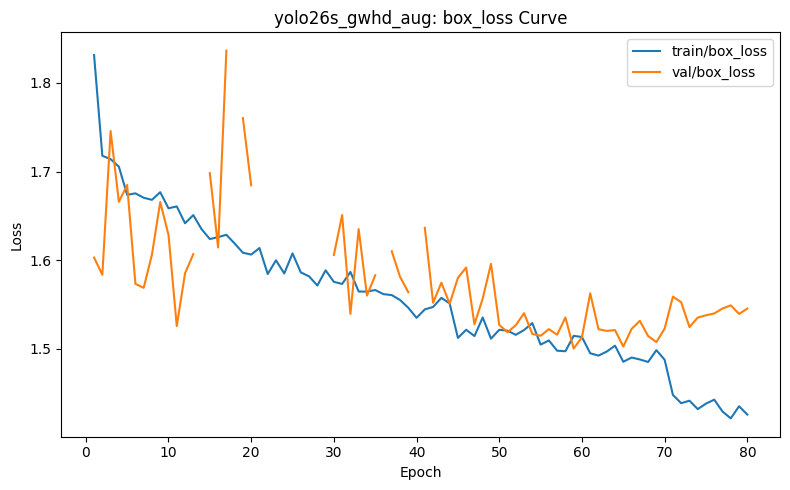

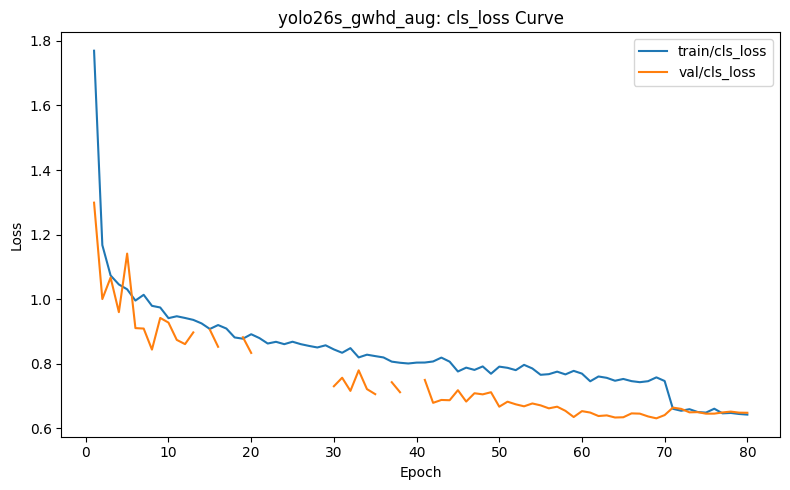

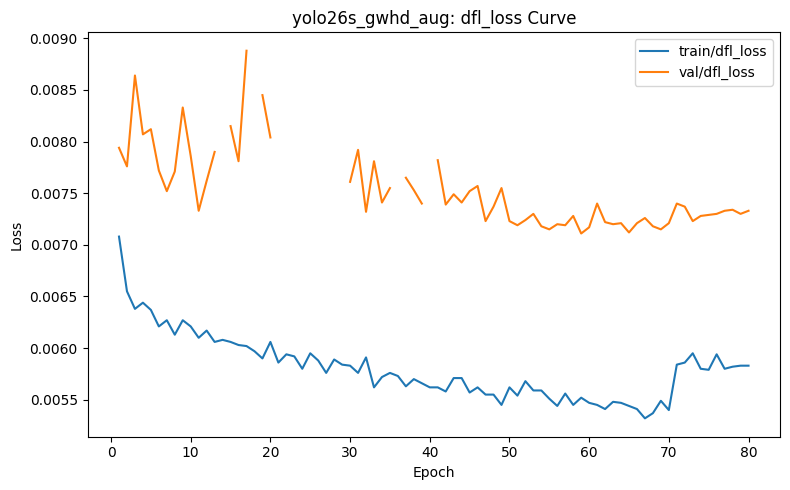

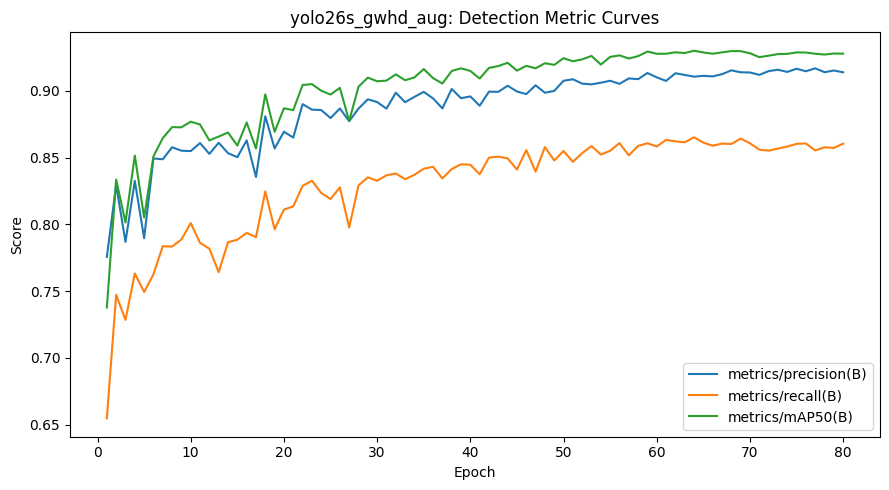

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
65,66,7589.38,1.44176,0.69844,0.00520,0.91748,0.86918,0.93203,0.51335,1.52944,0.62762,0.00723,0.000187,0.000187,0.000187
66,67,7704.78,1.44292,0.69047,0.00514,0.91168,0.87487,0.93111,0.50533,1.55412,0.63389,0.00733,0.000166,0.000166,0.000166
67,68,7819.33,1.43940,0.69423,0.00518,0.91517,0.86968,0.93110,0.50548,1.55715,0.63671,0.00736,0.000146,0.000146,0.000146
68,69,7935.30,1.45523,0.70222,0.00532,0.91495,0.87395,0.93131,0.50990,1.53891,0.62184,0.00726,0.000128,0.000128,0.000128
69,70,8049.46,1.44474,0.69263,0.00522,0.91748,0.87372,0.93268,0.51465,1.53446,0.62095,0.00725,0.000111,0.000111,0.000111


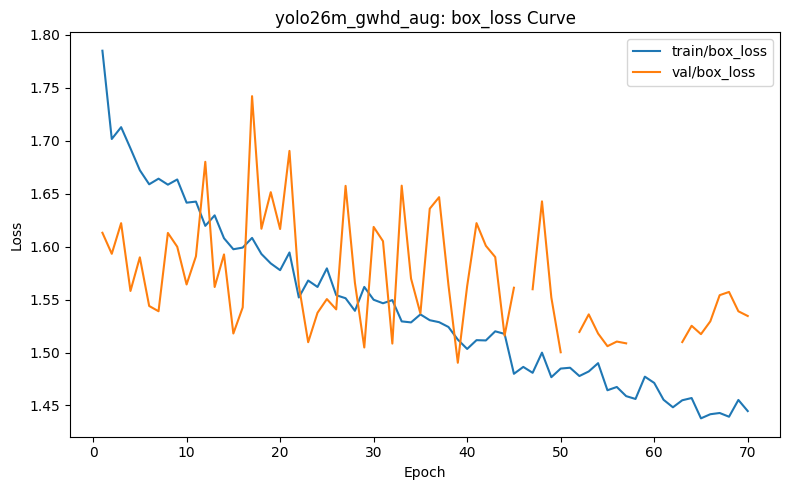

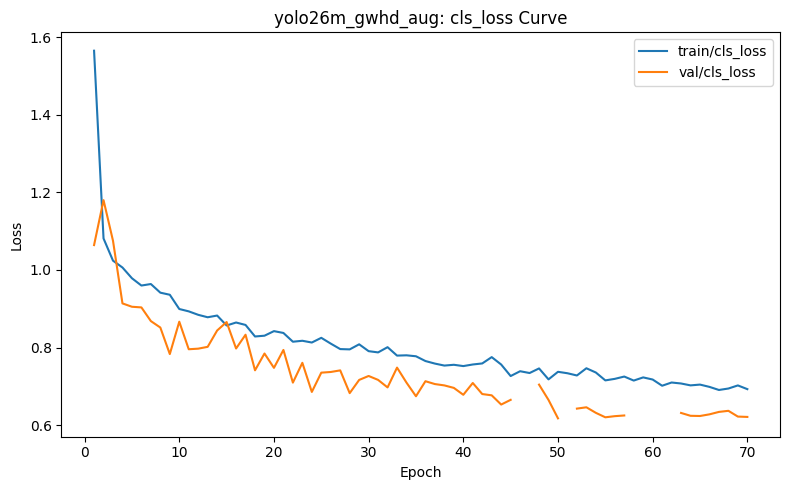

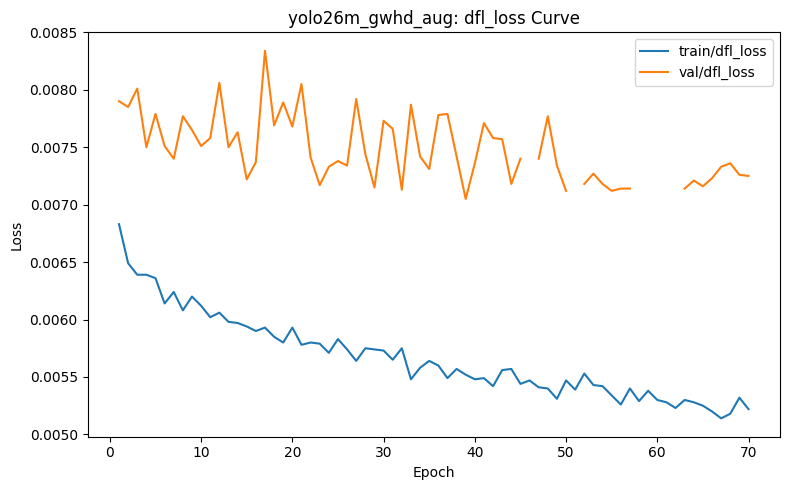

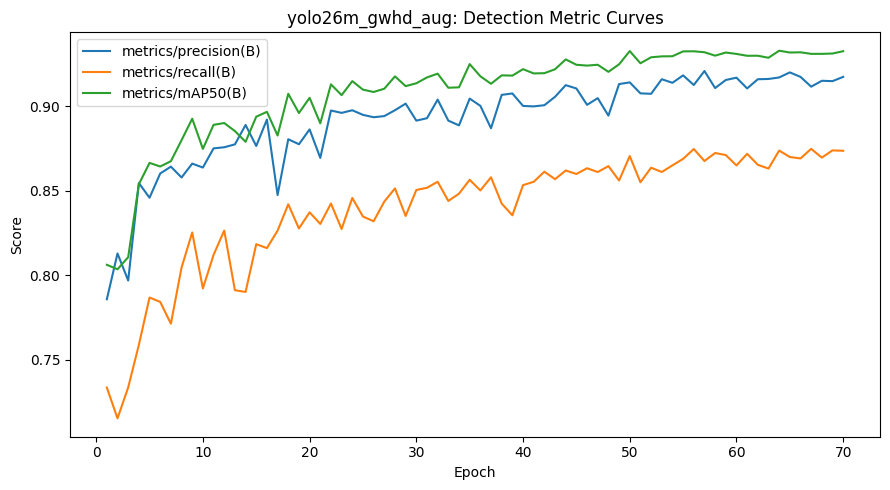

In [16]:
def plot_yolo_results_csv(exp_name):
    results_csv = RUNS_DIR / exp_name / "results.csv"

    if not results_csv.exists():
        print("Missing results.csv:", results_csv)
        return

    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]

    display(df.tail())

    for train_col, val_col in [
        ("train/box_loss", "val/box_loss"),
        ("train/cls_loss", "val/cls_loss"),
        ("train/dfl_loss", "val/dfl_loss")
    ]:
        if train_col in df.columns and val_col in df.columns:
            plt.figure(figsize=(8, 5))
            plt.plot(df["epoch"], df[train_col], label=train_col)
            plt.plot(df["epoch"], df[val_col], label=val_col)
            plt.title(f"{exp_name}: {train_col.split('/')[-1]} Curve")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.tight_layout()
            plt.savefig(FIG_DIR / f"{exp_name}_{train_col.split('/')[-1]}_curve.png", dpi=300)
            plt.show()

    metric_cols = [
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)"
    ]

    available_metrics = [c for c in metric_cols if c in df.columns]

    if available_metrics:
        plt.figure(figsize=(9, 5))
        for col in available_metrics:
            plt.plot(df["epoch"], df[col], label=col)
        plt.title(f"{exp_name}: Detection Metric Curves")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"{exp_name}_metric_curves.png", dpi=300)
        plt.show()


for exp_name in trained_model_paths.keys():
    plot_yolo_results_csv(exp_name)


## 15. Evaluate Models on Validation and Test Sets

Detection metrics:
- Precision
- Recall
- F1-score
- mAP@0.5

mAP@0.5 is used as the main detection metric for this experiment.


In [17]:
def safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def evaluate_yolo_model(weights_path, exp_name, split="test"):
    model = YOLO(weights_path)

    try:
        metrics = model.val(
            data=str(DATA_YAML),
            split=split,
            imgsz=IMG_SIZE_TRAIN,
            batch=BATCH_SIZE,
            device=DEVICE,
            plots=True,
            project=str(OUTPUT_DIR / "eval"),
            name=f"{exp_name}_{split}",
            end2end=False,
            verbose=False
        )
    except TypeError:
        metrics = model.val(
            data=str(DATA_YAML),
            split=split,
            imgsz=IMG_SIZE_TRAIN,
            batch=BATCH_SIZE,
            device=DEVICE,
            plots=True,
            project=str(OUTPUT_DIR / "eval"),
            name=f"{exp_name}_{split}",
            verbose=False
        )

    precision = safe_float(metrics.box.mp)
    recall = safe_float(metrics.box.mr)
    map50 = safe_float(metrics.box.map50)

    f1 = (2 * precision * recall) / (precision + recall + 1e-9)

    return {
        "model": exp_name,
        "split": split,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "mAP50": map50
    }


all_eval_results = []

for exp_name, paths in trained_model_paths.items():
    best_path = paths["best"]

    val_result = evaluate_yolo_model(best_path, exp_name, split="val")
    test_result = evaluate_yolo_model(best_path, exp_name, split="test")

    all_eval_results.append(val_result)
    all_eval_results.append(test_result)

eval_df = pd.DataFrame(all_eval_results)
display(eval_df)

eval_df.to_csv(OUTPUT_DIR / "detection_metrics_val_test.csv", index=False)
print("Saved:", OUTPUT_DIR / "detection_metrics_val_test.csv")


Ultralytics 8.4.79 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
YOLO26s summary (fused): 146 layers, 9,929,646 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2137.9±678.7 MB/s, size: 1954.0 KB)
val: Scanning /kaggle/working/gwhd_yolo/labels/val.cache... 1476 images, 28 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1476/1476 515.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 93/93 3.1it/s 30.4s
                   all       1476      44347      0.924      0.875      0.936      0.523
Speed: 1.0ms preprocess, 11.3ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to /kaggle/working/gwhd_outputs/eval/yolo26s_gwhd_aug_val
Ultralytics 8.4.79 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Te

,model,split,precision,recall,f1_score,mAP50
0,yolo26s_gwhd_aug,val,0.923656,0.874655,0.898488,0.935862
1,yolo26s_gwhd_aug,test,0.823964,0.670222,0.739183,0.736410
2,yolo26m_gwhd_aug,val,0.926774,0.880150,0.902860,0.937704
3,yolo26m_gwhd_aug,test,0.851075,0.691175,0.762836,0.762222


Saved: /kaggle/working/gwhd_outputs/detection_metrics_val_test.csv


## 16. Model Comparison Visualization

,model,split,precision,recall,f1_score,mAP50
1,yolo26s_gwhd_aug,test,0.823964,0.670222,0.739183,0.736410
3,yolo26m_gwhd_aug,test,0.851075,0.691175,0.762836,0.762222


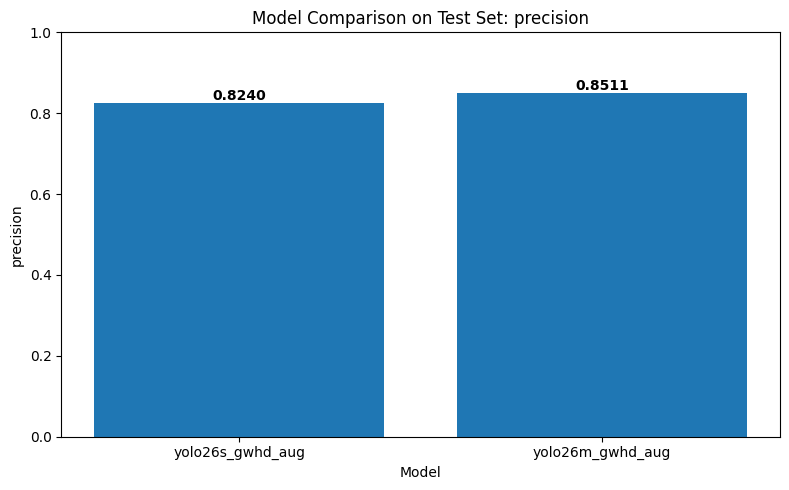

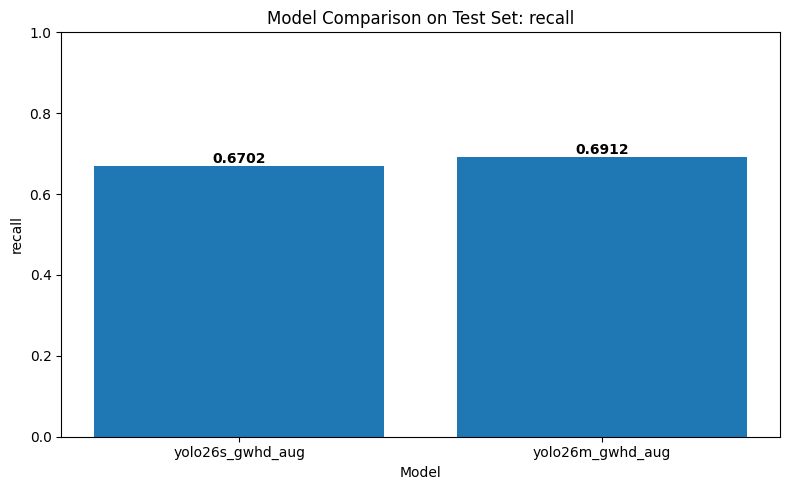

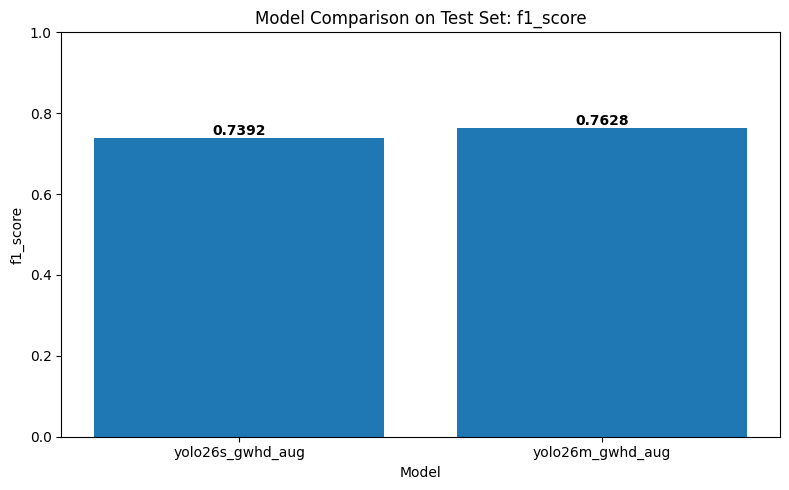

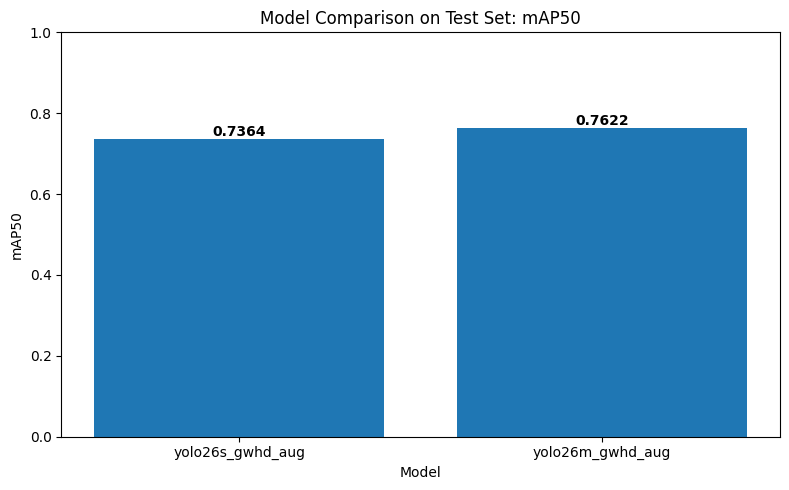

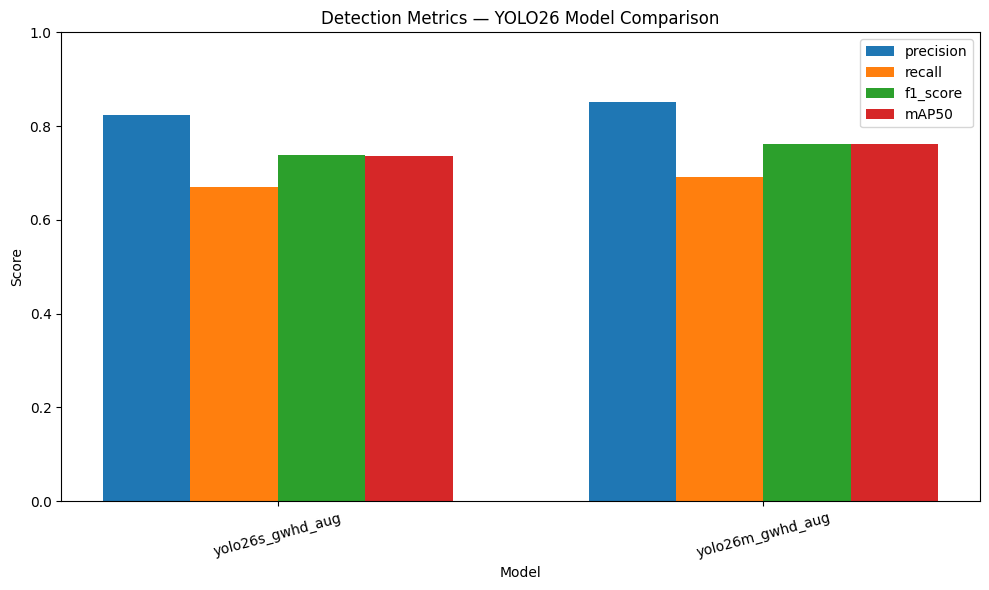

In [18]:
test_metrics_df = eval_df[eval_df["split"] == "test"].copy()

display(test_metrics_df)

metrics_to_plot = ["precision", "recall", "f1_score", "mAP50"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(test_metrics_df["model"], test_metrics_df[metric])
    plt.title(f"Model Comparison on Test Set: {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.ylim(0, 1)

    for i, v in enumerate(test_metrics_df[metric]):
        plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontweight="bold")

    plt.tight_layout()
    plt.savefig(FIG_DIR / f"model_comparison_{metric}.png", dpi=300)
    plt.show()


x = np.arange(len(test_metrics_df["model"]))
width = 0.18

plt.figure(figsize=(10, 6))
for i, metric in enumerate(metrics_to_plot):
    plt.bar(x + i * width, test_metrics_df[metric], width, label=metric)

plt.xticks(x + width * 1.5, test_metrics_df["model"], rotation=15)
plt.title("Detection Metrics — YOLO26 Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "detection_metrics_model_comparison.png", dpi=300)
plt.show()


## 17. Select Best Model

The best model is selected using validation mAP@0.5. The final performance is then reported on the test set.


In [19]:
val_metrics_df = eval_df[eval_df["split"] == "val"].copy()
best_row = val_metrics_df.sort_values("mAP50", ascending=False).iloc[0]

BEST_MODEL_NAME = best_row["model"]
BEST_MODEL_PATH = trained_model_paths[BEST_MODEL_NAME]["best"]

print("Best model selected from validation performance:")
print("Model:", BEST_MODEL_NAME)
print("Weights:", BEST_MODEL_PATH)

best_model = YOLO(BEST_MODEL_PATH)


Best model selected from validation performance:
Model: yolo26m_gwhd_aug
Weights: /kaggle/working/runs_gwhd/yolo26m_gwhd_aug/weights/best.pt


## 18. Prediction Visualization: Ground Truth vs Predicted Boxes

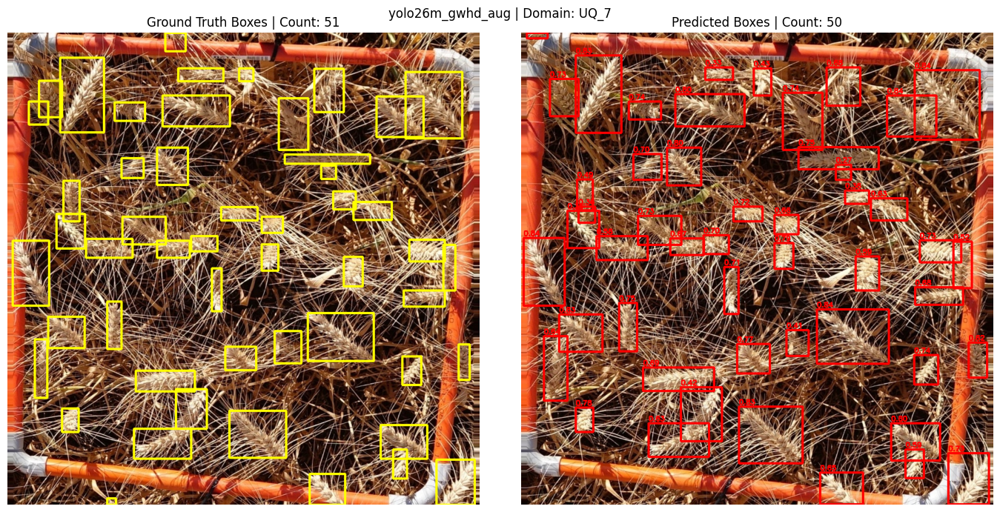

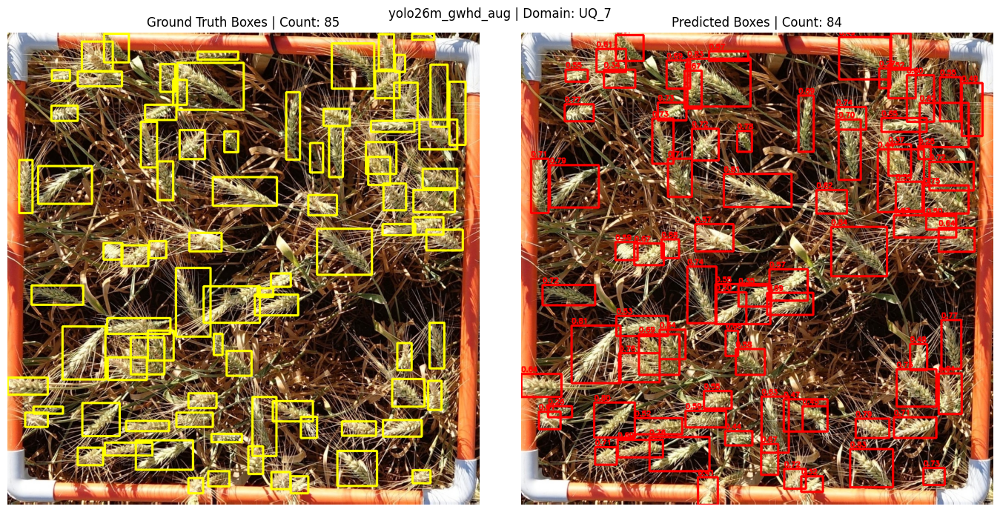

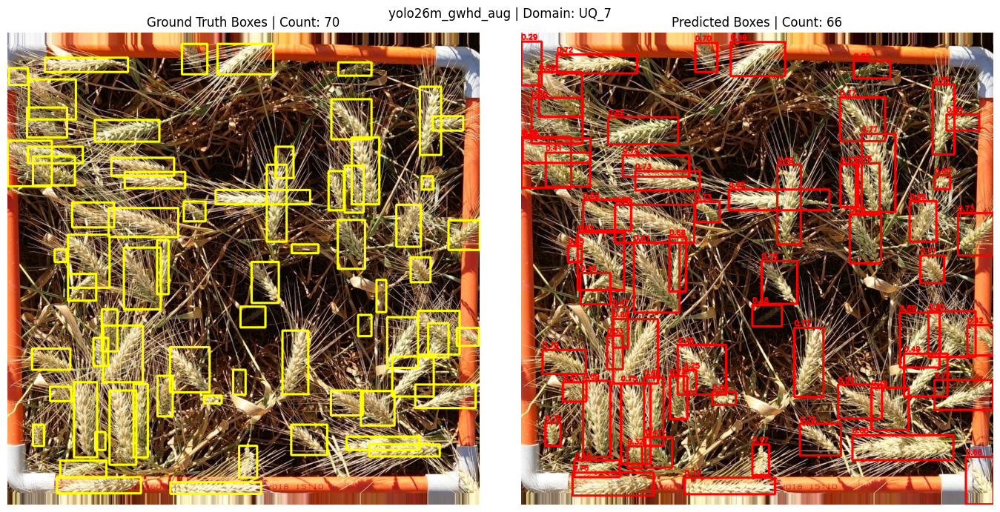

In [20]:
def draw_pred_boxes(image_rgb, result, color=(255, 0, 0), thickness=3):
    output = image_rgb.copy()

    if result.boxes is None or len(result.boxes) == 0:
        return output

    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()

    for box, conf in zip(boxes, confs):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(output, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(
            output,
            f"{conf:.2f}",
            (x1, max(0, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

    return output


def predict_one_image(model, image_path, conf=0.25, iou=0.50):
    try:
        return model.predict(
            source=str(image_path),
            imgsz=IMG_SIZE_TRAIN,
            conf=conf,
            iou=iou,
            end2end=False,
            verbose=False
        )[0]
    except TypeError:
        return model.predict(
            source=str(image_path),
            imgsz=IMG_SIZE_TRAIN,
            conf=conf,
            iou=iou,
            verbose=False
        )[0]


def show_gt_vs_prediction(df, split="test", idx=0, conf=0.25, iou=0.50, save_name=None):
    row = df.iloc[idx]
    image_path = YOLO_DIR / "images" / split / row["image_name"]

    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    gt_img = draw_boxes_on_image(image_path, row["boxes"], color=(255, 255, 0), thickness=3)
    result = predict_one_image(best_model, image_path, conf=conf, iou=iou)
    pred_img = draw_pred_boxes(image_rgb, result, color=(255, 0, 0), thickness=3)

    gt_count = row["box_count"]
    pred_count = len(result.boxes) if result.boxes is not None else 0

    plt.figure(figsize=(14, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(gt_img)
    plt.title(f"Ground Truth Boxes | Count: {gt_count}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(pred_img)
    plt.title(f"Predicted Boxes | Count: {pred_count}")
    plt.axis("off")

    plt.suptitle(f"{BEST_MODEL_NAME} | Domain: {row['domain']}")
    plt.tight_layout()

    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=300, bbox_inches="tight")

    plt.show()


show_gt_vs_prediction(df_test, split="test", idx=0, save_name="gt_vs_prediction_sample_1.png")
show_gt_vs_prediction(df_test, split="test", idx=5, save_name="gt_vs_prediction_sample_2.png")
show_gt_vs_prediction(df_test, split="test", idx=10, save_name="gt_vs_prediction_sample_3.png")


## 19. Prediction Heatmap with Boxes

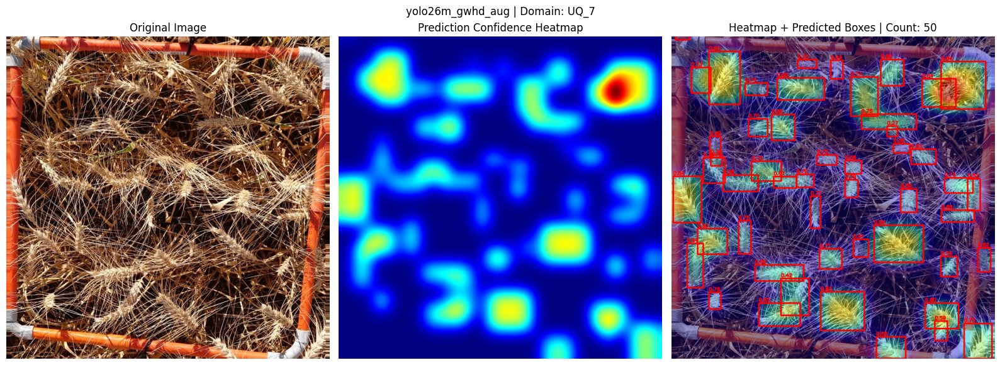

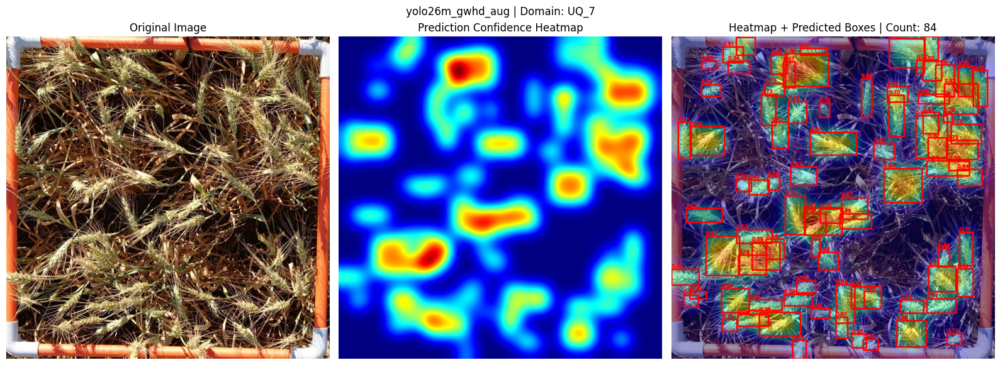

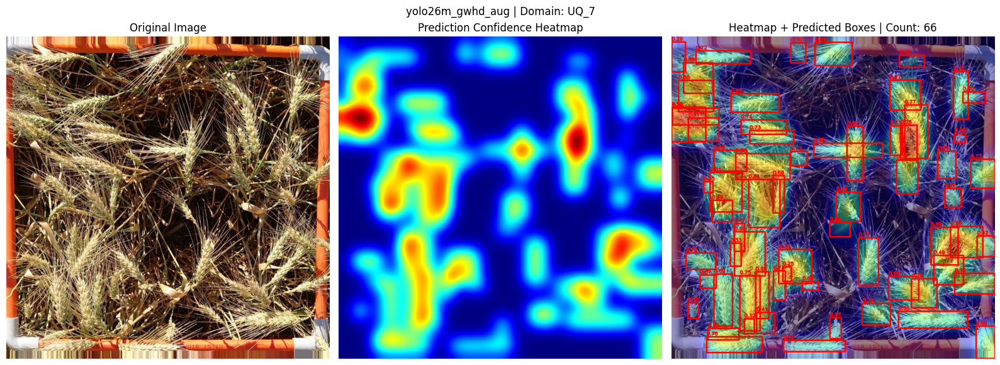

In [21]:
def show_prediction_heatmap(df, split="test", idx=0, conf=0.25, iou=0.50, save_name=None):
    row = df.iloc[idx]
    image_path = YOLO_DIR / "images" / split / row["image_name"]

    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(image_path)

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h, w = image_rgb.shape[:2]

    result = predict_one_image(best_model, image_path, conf=conf, iou=iou)
    heat = np.zeros((h, w), dtype=np.float32)

    if result.boxes is not None and len(result.boxes) > 0:
        boxes = result.boxes.xyxy.cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()

        for box, score in zip(boxes, confs):
            x1, y1, x2, y2 = map(int, box)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w - 1, x2), min(h - 1, y2)

            if x2 > x1 and y2 > y1:
                heat[y1:y2, x1:x2] += float(score)

    heat = cv2.GaussianBlur(heat, (0, 0), sigmaX=25, sigmaY=25)

    if heat.max() > 0:
        heat_norm = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    else:
        heat_norm = heat

    heat_uint8 = np.uint8(255 * heat_norm)
    heat_color = cv2.applyColorMap(heat_uint8, cv2.COLORMAP_JET)
    heat_color = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(image_rgb, 0.60, heat_color, 0.40, 0)
    overlay_boxes = draw_pred_boxes(overlay, result, color=(255, 0, 0), thickness=3)

    pred_count = len(result.boxes) if result.boxes is not None else 0

    plt.figure(figsize=(16, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heat_color)
    plt.title("Prediction Confidence Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay_boxes)
    plt.title(f"Heatmap + Predicted Boxes | Count: {pred_count}")
    plt.axis("off")

    plt.suptitle(f"{BEST_MODEL_NAME} | Domain: {row['domain']}")
    plt.tight_layout()

    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=300, bbox_inches="tight")

    plt.show()


show_prediction_heatmap(df_test, split="test", idx=0, save_name="prediction_heatmap_sample_1.png")
show_prediction_heatmap(df_test, split="test", idx=5, save_name="prediction_heatmap_sample_2.png")
show_prediction_heatmap(df_test, split="test", idx=10, save_name="prediction_heatmap_sample_3.png")


## 20. Count-Based Yield Potential Evaluation

In [22]:
def predict_counts_for_split(model, df, split="test", conf=0.25, iou=0.50):
    records = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Counting predictions on {split}"):
        image_path = YOLO_DIR / "images" / split / row["image_name"]
        result = predict_one_image(model, image_path, conf=conf, iou=iou)

        if result.boxes is None or len(result.boxes) == 0:
            pred_count = 0
            mean_conf = 0.0
        else:
            pred_count = len(result.boxes)
            mean_conf = float(result.boxes.conf.mean().cpu().item())

        records.append({
            "image_name": row["image_name"],
            "domain": row["domain"],
            "gt_count": int(row["box_count"]),
            "pred_count": int(pred_count),
            "absolute_error": abs(int(row["box_count"]) - int(pred_count)),
            "mean_confidence": mean_conf
        })

    return pd.DataFrame(records)


confidence_thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]
nms_iou_thresholds = [0.50, 0.60, 0.70]

threshold_results = []

for conf_th in confidence_thresholds:
    for nms_iou in nms_iou_thresholds:
        val_count_df = predict_counts_for_split(
            best_model,
            df_val,
            split="val",
            conf=conf_th,
            iou=nms_iou
        )

        gt = val_count_df["gt_count"].values
        pred = val_count_df["pred_count"].values

        mae = mean_absolute_error(gt, pred)
        rmse = math.sqrt(mean_squared_error(gt, pred))
        r2 = r2_score(gt, pred)

        non_zero_mask = gt != 0
        mape = np.mean(np.abs((gt[non_zero_mask] - pred[non_zero_mask]) / gt[non_zero_mask])) * 100

        threshold_results.append({
            "confidence_threshold": conf_th,
            "nms_iou": nms_iou,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "MAPE_percent": mape,
            "avg_gt_count": np.mean(gt),
            "avg_pred_count": np.mean(pred)
        })

threshold_df = pd.DataFrame(threshold_results).sort_values("MAE").reset_index(drop=True)
display(threshold_df)

threshold_df.to_csv(OUTPUT_DIR / "validation_conf_iou_tuning.csv", index=False)

best_row = threshold_df.sort_values("RMSE", ascending=True).iloc[0]

best_conf = float(best_row["confidence_threshold"])
best_nms_iou = float(best_row["nms_iou"])

print("Best confidence threshold from validation RMSE:", best_conf)
print("Best NMS IoU from validation RMSE:", best_nms_iou)


count_df = predict_counts_for_split(
    best_model,
    df_test,
    split="test",
    conf=best_conf,
    iou=best_nms_iou
)

display(count_df.head())
count_df.to_csv(OUTPUT_DIR / "test_count_predictions.csv", index=False)
print("Saved:", OUTPUT_DIR / "test_count_predictions.csv")


gt_total = count_df["gt_count"].sum()
pred_total = count_df["pred_count"].sum()

difference = gt_total - pred_total
under_count_percentage = (difference / gt_total) * 100

total_count_summary = pd.DataFrame({
    "Type": [
        "Ground truth total heads",
        "Predicted total heads",
        "Difference",
        "Under-count percentage"
    ],
    "Count": [
        f"{gt_total:,}",
        f"{pred_total:,}",
        f"{difference:,} fewer",
        f"{under_count_percentage:.2f}%"
    ]
})

display(total_count_summary)
total_count_summary.to_csv(OUTPUT_DIR / "total_count_summary.csv", index=False)
print("Saved:", OUTPUT_DIR / "total_count_summary.csv")


Counting predictions on val:   0%|          | 0/1476 [00:00<?, ?it/s]

Counting predictions on val:   0%|          | 0/1476 [00:00<?, ?it/s]

Counting predictions on val:   0%|          | 0/1476 [00:00<?, ?it/s]

Counting predictions on val:   0%|          | 0/1476 [00:00<?, ?it/s]

Counting predictions on val:   0%|          | 0/1476 [00:00<?, ?it/s]

...

Counting predictions on test:   0%|          | 0/1382 [00:00<?, ?it/s]

,image_name,domain,gt_count,pred_count,absolute_error,mean_confidence
0,255b6ca9fea63f44125e5174bc932470b604c760430715...,UQ_7,51,52,1,0.635301
1,7f5eb37cab658de6fd0d688bf27f16e423794fed6184d8...,UQ_7,75,67,8,0.573517
2,7bcfff43b356f4a94948367782aa704a37ff4579baf45d...,UQ_7,94,88,6,0.623433
3,e535384eda9d0f9c6ac57dd9397d5d614e4cad48c144d8...,UQ_7,41,38,3,0.621854
4,66e9fa7379fd7b7fd64024ac1b03b8e56f9ad020c10635...,UQ_7,67,77,10,0.618985


Saved: /kaggle/working/gwhd_outputs/test_count_predictions.csv


,Type,Count
0,Ground truth total heads,"67,424"
1,Predicted total heads,"57,635"
2,Difference,"9,789 fewer"
3,Under-count percentage,14.52%


Saved: /kaggle/working/gwhd_outputs/total_count_summary.csv


In [23]:
gt = count_df["gt_count"].values
pred = count_df["pred_count"].values

mae = mean_absolute_error(gt, pred)
rmse = math.sqrt(mean_squared_error(gt, pred))
r2 = r2_score(gt, pred)

# MAPE: avoid division by zero
non_zero_mask = gt != 0
mape = np.mean(np.abs((gt[non_zero_mask] - pred[non_zero_mask]) / gt[non_zero_mask])) * 100

count_metrics = pd.DataFrame([{
    "model": BEST_MODEL_NAME,
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "MAPE_percent": mape,
    "avg_gt_count": np.mean(gt),
    "avg_pred_count": np.mean(pred)
}])

display(count_metrics)
count_metrics.to_csv(OUTPUT_DIR / "counting_metrics.csv", index=False)
print("Saved:", OUTPUT_DIR / "counting_metrics.csv")

,model,MAE,RMSE,R2,MAPE_percent,avg_gt_count,avg_pred_count
0,yolo26m_gwhd_aug,8.08466,10.742177,0.854716,22.920314,48.787265,41.704052


Saved: /kaggle/working/gwhd_outputs/counting_metrics.csv


## 21. Counting Visualization

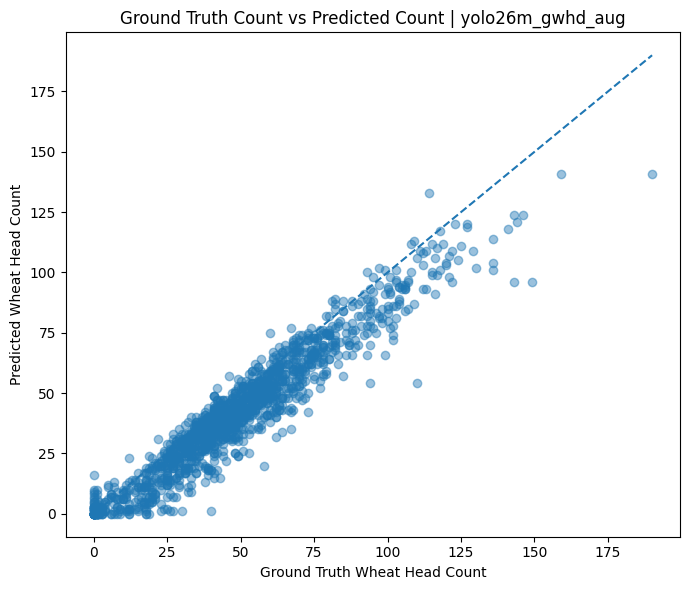

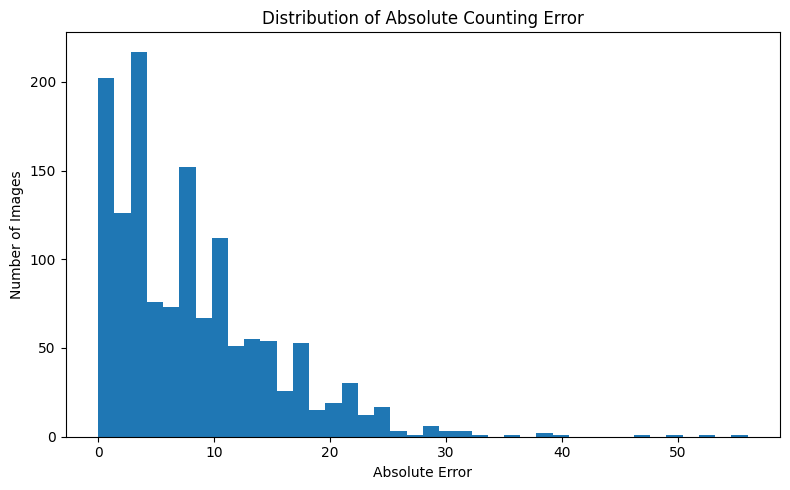

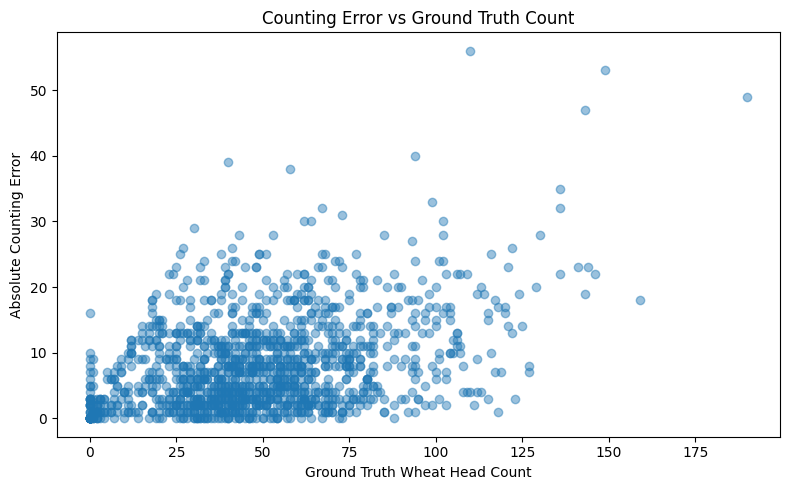

In [24]:
plt.figure(figsize=(7, 6))
plt.scatter(count_df["gt_count"], count_df["pred_count"], alpha=0.45)

max_count = max(count_df["gt_count"].max(), count_df["pred_count"].max())
plt.plot([0, max_count], [0, max_count], linestyle="--")

plt.title(f"Ground Truth Count vs Predicted Count | {BEST_MODEL_NAME}")
plt.xlabel("Ground Truth Wheat Head Count")
plt.ylabel("Predicted Wheat Head Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "gt_vs_pred_count_scatter.png", dpi=300)
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(count_df["absolute_error"], bins=40)
plt.title("Distribution of Absolute Counting Error")
plt.xlabel("Absolute Error")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(FIG_DIR / "absolute_count_error_distribution.png", dpi=300)
plt.show()


plt.figure(figsize=(8, 5))
plt.scatter(count_df["gt_count"], count_df["absolute_error"], alpha=0.45)
plt.title("Counting Error vs Ground Truth Count")
plt.xlabel("Ground Truth Wheat Head Count")
plt.ylabel("Absolute Counting Error")
plt.tight_layout()
plt.savefig(FIG_DIR / "count_error_vs_gt_count.png", dpi=300)
plt.show()

## 22. Domain-wise Counting Evaluation

In [25]:
def rmse_func(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

domain_count_summary = count_df.groupby("domain").apply(
    lambda g: pd.Series({
        "images": len(g),
        "gt_total_count": g["gt_count"].sum(),
        "pred_total_count": g["pred_count"].sum(),
        "avg_gt_count": g["gt_count"].mean(),
        "avg_pred_count": g["pred_count"].mean(),
        "MAE": mean_absolute_error(g["gt_count"], g["pred_count"]),
        "RMSE": rmse_func(g["gt_count"], g["pred_count"]),
        "mean_absolute_error_per_image": g["absolute_error"].mean()
    })
).reset_index()

domain_count_summary = domain_count_summary.sort_values("MAE", ascending=False)

display(domain_count_summary.head(20))
domain_count_summary.to_csv(OUTPUT_DIR / "domain_wise_counting_summary.csv", index=False)
print("Saved:", OUTPUT_DIR / "domain_wise_counting_summary.csv")

/tmp/ipykernel_22/354808978.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  domain_count_summary = count_df.groupby("domain").apply(


,domain,images,gt_total_count,pred_total_count,avg_gt_count,avg_pred_count,MAE,RMSE,mean_absolute_error_per_image
15,UQ_8,41.0,4835.0,4175.0,117.926829,101.829268,16.097561,19.566023,16.097561
16,UQ_9,33.0,2886.0,2368.0,87.454545,71.757576,15.696970,18.837422,15.696970
7,KSU_4,60.0,3285.0,2515.0,54.750000,41.916667,12.833333,14.291023,12.833333
17,Ukyoto_1,60.0,2670.0,1958.0,44.500000,32.633333,12.433333,14.979987,12.433333
4,KSU_1,100.0,6435.0,5383.0,64.350000,53.830000,10.520000,12.063996,10.520000
5,KSU_2,100.0,5302.0,4368.0,53.020000,43.680000,9.360000,12.039934,9.360000
10,Terraref_1,144.0,3360.0,2224.0,23.333333,15.444444,9.208333,11.374924,9.208333
12,UQ_10,106.0,8629.0,7671.0,81.405660,72.367925,9.113208,10.796575,9.113208
1,CIMMYT_1,69.0,2843.0,2225.0,41.202899,32.246377,9.014493,10.760906,9.014493
11,Terraref_2,106.0,1274.0,493.0,12.018868,4.650943,8.707547,11.555036,8.707547


Saved: /kaggle/working/gwhd_outputs/domain_wise_counting_summary.csv


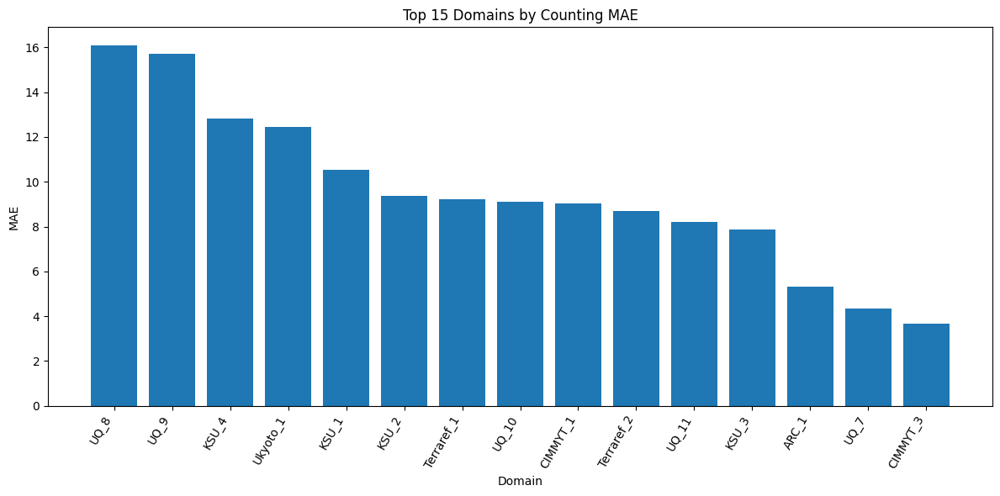

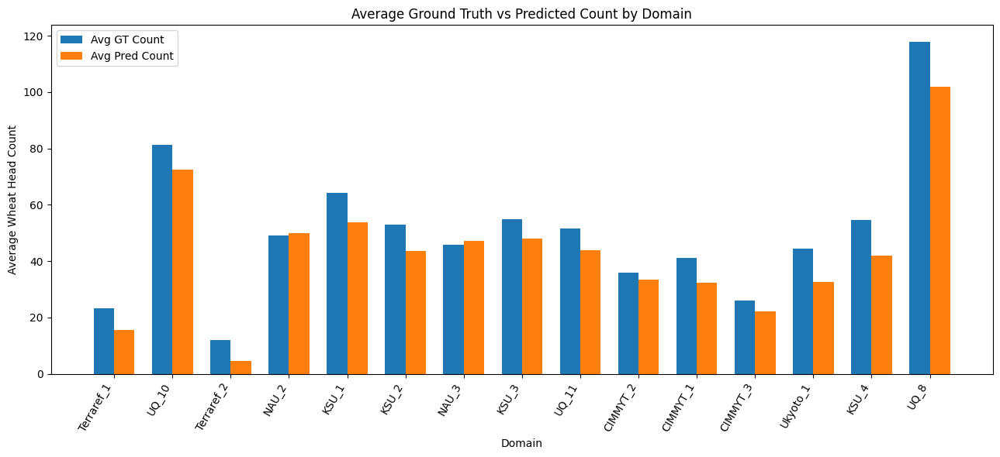

In [26]:
top_error_domains = domain_count_summary.head(15)

plt.figure(figsize=(12, 6))
plt.bar(top_error_domains["domain"], top_error_domains["MAE"])
plt.title("Top 15 Domains by Counting MAE")
plt.xlabel("Domain")
plt.ylabel("MAE")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_15_domain_counting_mae.png", dpi=300)
plt.show()


top_image_domains = domain_count_summary.sort_values("images", ascending=False).head(15)

x = np.arange(len(top_image_domains))
width = 0.35

plt.figure(figsize=(13, 6))
plt.bar(x - width/2, top_image_domains["avg_gt_count"], width, label="Avg GT Count")
plt.bar(x + width/2, top_image_domains["avg_pred_count"], width, label="Avg Pred Count")
plt.xticks(x, top_image_domains["domain"], rotation=60, ha="right")
plt.title("Average Ground Truth vs Predicted Count by Domain")
plt.xlabel("Domain")
plt.ylabel("Average Wheat Head Count")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "domain_avg_gt_vs_pred_count.png", dpi=300)
plt.show()

## 23. Save Best Model Copy and All Outputs

In [27]:
best_copy_path = OUTPUT_DIR / f"{BEST_MODEL_NAME}_best.pt"
shutil.copy2(BEST_MODEL_PATH, best_copy_path)

print("Best model copied to:", best_copy_path)

summary_text = f"""
Project: GWHD 2021 Wheat Head Detection and Count-Based Yield Potential Estimation

Best Model: {BEST_MODEL_NAME}
Best Weights: {best_copy_path}

Detection Metrics:
{eval_df.to_string(index=False)}

Counting Metrics:
{count_metrics.to_string(index=False)}

Important Note:
This notebook estimates count-based yield potential using wheat head count.
It does not estimate actual kg/ha yield because actual yield requires additional agronomic variables.
"""

with open(OUTPUT_DIR / "result_summary.txt", "w") as f:
    f.write(summary_text)

print(summary_text)

Best model copied to: /kaggle/working/gwhd_outputs/yolo26m_gwhd_aug_best.pt

Project: GWHD 2021 Wheat Head Detection and Count-Based Yield Potential Estimation

Best Model: yolo26m_gwhd_aug
Best Weights: /kaggle/working/gwhd_outputs/yolo26m_gwhd_aug_best.pt

Detection Metrics:
           model split  precision   recall  f1_score    mAP50
yolo26s_gwhd_aug   val   0.923656 0.874655  0.898488 0.935862
yolo26s_gwhd_aug  test   0.823964 0.670222  0.739183 0.736410
yolo26m_gwhd_aug   val   0.926774 0.880150  0.902860 0.937704
yolo26m_gwhd_aug  test   0.851075 0.691175  0.762836 0.762222

Counting Metrics:
           model     MAE      RMSE       R2  MAPE_percent  avg_gt_count  avg_pred_count
yolo26m_gwhd_aug 8.08466 10.742177 0.854716     22.920314     48.787265       41.704052

Important Note:
This notebook estimates count-based yield potential using wheat head count.
It does not estimate actual kg/ha yield because actual yield requires additional agronomic variables.

